# **Expected Goals in Lacrosse**


This lesson introduces students to Logistic Regression and Support Vector Machines (SVMs) in modeling an Expected Goals Model using lacrosse location data. The main focus of the lesson is comparing performance between logistic regression and SVM for an imbalanced data set, and how to approach class imbalance scenarios. In this lesson we will explore Premier Lacrosse League shot location data from the first three years of the league (2019-2021).

# **Welcome Message and Introduction**

*   https://youtube.com/shorts/TklOjvzMv_0?feature=share





# **Lesson Objectives**


*   Explain the structure of an Expected Goals (xG) model and evaluate its usefulness in lacrosse analytics.
*   Interpret logistic regression models and analyze the meaning of their coefficients in context.
*   Compare and contrast Support Vector Machines (SVMs), including their key advantages and limitations.
*   Construct and evaluate a baseline (dummy) model for performance comparison.
*   Diagnose class imbalance in sports datasets and apply appropriate techniques to address it, justifying their impact on model performance.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv() #location of data

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
df["Result"].value_counts()

Look at the value counts of each of the possible outcomes of a shot. Does anything stick out? Should we be concerned about the balance of classes?

In [ ]:
goals = df[df["Result"] == "GOAL"]
non_goals = df[df["Result"] != "GOAL"]

In [ ]:
df["goal"] = (df["Result"] == "GOAL").astype(int)
df["goal"].value_counts()

In [ ]:
df["goal"].value_counts(normalize=True) * 100

In sports analytics and specifically lacrosse, events like goals are rare compared to non-goals. So when exploring the data it is common to find that class imbalance exists. This will have to be addressed when modeling takes place.

In [ ]:
#The mean location of a shot that results in a goal
goals_x_center = goals["X"].mean()
goals_y_center = goals["Y"].mean()

goals_x_center, goals_y_center

In [ ]:
goal_center = (1000,892)
left_post = (964, 892)
right_post = (1036, 892)

# The Estimated Center of the Goal and Pipes

In [ ]:
import matplotlib.pyplot as plt

#Plotting the location of where mean goals scored
plt.figure(figsize=(6,8))
plt.scatter(df["X"], df["Y"], alpha=0.1, label="All shots")
plt.scatter(goals_x_center, goals_y_center,
            color="red", s=100, label="Mean location of Goals (estimated)")
plt.gca()  # matches screen coordinates
plt.legend()
plt.title("PLL Shot Chart with Estimated Goal Center")
plt.show()

* What are the coordinates for the center of the goal?
* What are the coordinates for the mean location of goals?

In [ ]:
goal_center = (1000,892)
left_post = (964, 892)
right_post = (1036, 892)

In [ ]:
#Plotting the location of where mean goals scored
plt.figure(figsize=(6,8))
plt.scatter(df["X"], df["Y"], alpha=0.1, label="All shots")
plt.scatter(goals_x_center, goals_y_center,
            color="red", s=100, label="Mean location of Goals (estimated)")
plt.scatter(goal_center[0], goal_center[1], color = "green", s=20, label = "Center of the Goal")
plt.scatter(left_post[0], left_post[1], color = "orange", s=10, label = "left post")
plt.scatter(right_post[0], right_post[1], color = "orange", s=10, label = "right posts")
plt.gca()  # matches screen coordinates
plt.legend()
plt.title("PLL Shot Chart with Estimated Goal Center")
plt.show()

For those not familiar with the game of lacrosse, the goal is a 6 ft by 6 ft net with metal posts. The plot above accurately plots the side pipes and the center of the net. The goal line goes from post to post and when the ball crosses the goal line it is called a goal. The goal line extended is the goal line but extended from sideline to sideline.

In [ ]:
#subtracting the coordinates of the center of the goal to re-coordinate the data on (0,0)
df["dx"] = df["X"] - 1000
df["dy"] = df["Y"] - 892

# Calculating Shot Distance and Shot Angle

In [ ]:
#Calculating shot distance
df["shot_distance"] = np.sqrt(df["dx"]**2 + df["dy"]**2)

In [ ]:
#Calculating shot angle
df["shot_angle"] = np.arctan2(abs(df["dx"]), df["dy"])

## Shot Distance Plots

In [ ]:
#Distribution of Shot Distances

plt.figure(figsize=(8,5))
plt.hist(df["shot_distance"], bins=50)
plt.xlabel("Shot Distance (in)")
plt.ylabel("Number of Shots")
plt.title("Distribution of Shot Distances")
plt.show()

In [ ]:
df["shot_angle_deg"] = np.degrees(df["shot_angle"])
df["shot_angle_deg"]
goals = df[df["Result"] == "GOAL"]
misses = df[df["Result"] != "GOAL"]

plt.figure(figsize=(8,5))
plt.hist(goals["shot_distance"], bins=40, density=True, alpha=0.6, label="Goals")
plt.hist(misses["shot_distance"], bins=40, density=True, alpha=0.6, label="Non-goals")
plt.xlabel("Shot Distance")
plt.ylabel("Density")
plt.title("Shot Distance by Outcome")
plt.legend()
plt.show()

## Shot Angle Plots

In [ ]:
#Distribution plot for shot angles

plt.figure(figsize=(8,5))
plt.hist(df["shot_angle_deg"], bins=40)
plt.xlabel("Shot Angle (Degrees)")
plt.ylabel("Number of Shots")
plt.title("Distribution of Shot Angles")
plt.show()

In [ ]:
#Goals vs. No Goals by shot angle

plt.figure(figsize=(8,5))
plt.hist(goals["shot_angle_deg"], bins=35, density=True, alpha=0.6, label="Goals")
plt.hist(misses["shot_angle_deg"], bins=35, density=True, alpha=0.6, label="No Goal")

plt.xlabel("Shot Angle (degrees)")
plt.ylabel("Density")
plt.title("Shot Angle Distribution: Goal vs No Goal")
plt.legend()
plt.show()

## Redefining Shot angle to the Posts

In [ ]:
#redefining shot angle
#redefine posts
xL, yL = -36, 0
xR, yR = 36, 0

#Vectors from shot to posts
SLx = xL - df["dx"]
SLy = yL - df["dy"]

SRx = xR - df["dx"]
SRy = yR - df["dy"]

#dot product formula
dot = SLx * SRx + SLy * SRy

mag_SL = np.sqrt(SLx**2 + SLy**2)
mag_SR = np.sqrt(SRx**2 + SRy**2)

df["true_angle"] = np.arccos(dot / (mag_SL * mag_SR))
df["true_angle_deg"] = np.degrees(df["true_angle"])

#check
df["true_angle_deg"].describe()

## New shot angle plots

In [ ]:
#Distribution plot for True shot angles

plt.figure(figsize=(8,5))
plt.hist(df["true_angle_deg"], bins=40)
plt.xlabel("True Shot Angle (Degrees)")
plt.ylabel("Number of Shots")
plt.title("Distribution of Shot Angles")
plt.show()

In [ ]:
#Goals vs. No Goals by true shot angle
#redefine goals and misses since we added true shot angle
goals = df[df["Result"] == "GOAL"]
misses = df[df["Result"] != "GOAL"]

plt.figure(figsize=(8,5))
plt.hist(goals["true_angle_deg"], bins=35, density=True, alpha=0.6, label="Goals")
plt.hist(misses["true_angle_deg"], bins=35, density=True, alpha=0.6, label="No Goal")

plt.xlabel("True Shot Angle (degrees)")
plt.ylabel("Density")
plt.title("Shot Angle Distribution: Goal vs No Goal")
plt.legend()
plt.show()

In [ ]:
# Prepare Heatmap
# Choose reasonable bin counts
# distance and angle are continuous variables so that is why we bin them
dist_bins = 20
angle_bins = 20

df["dist_bin"] = pd.cut(df["shot_distance"], bins=dist_bins)
df["angle_bin"] = pd.cut(df["true_angle_deg"], bins=angle_bins)

# compute goal probability in each cell
# rows -> distance bins
# columns -> angle bins
# values -> goal probability
heatmap_data = (
    df.groupby(["dist_bin", "angle_bin"])["goal"]
      .mean()
      .unstack()
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    heatmap_data,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Goal Probability")

plt.xlabel("Angle Bin")
plt.ylabel("Distance Bin (inches)")
plt.title("Goal Probability by True Shot Angle and Distance")

plt.show()

### Shot angle and distance outcome plots

In [ ]:
non_goals = df[df["goal"] == 0]

plt.figure(figsize=(8,6))

plt.scatter(
    non_goals["true_angle_deg"],
    non_goals["shot_distance"],
    alpha=0.1,
    label="No Goal"
)

plt.scatter(
    goals["true_angle_deg"],
    goals["shot_distance"],
    alpha=0.6,
    label="Goal"
)

plt.xlabel("True Shot Angle (Degrees)")
plt.ylabel("Shot Distance")
plt.title("Shot Outcomes in Angle–Distance Space")
plt.legend()

plt.show()

Does this relationship between shot angle and distance surprise you? Why or why not?    

In [ ]:
#split the data into assisted and unassisted
assisted = df[df["Assisted"] == "Assisted"]
unassisted = df[df["Assisted"] == "Unassisted"]

### Assisted vs. Unassisted

In [ ]:
#Scatter plot of all shots (assisted v. unassisted)
plt.figure(figsize=(8,6))

plt.scatter(
    unassisted["true_angle_deg"],
    unassisted["shot_distance"],
    alpha=0.1,
    label="Unassisted"
)

plt.scatter(
    assisted["true_angle_deg"],
    assisted["shot_distance"],
    alpha=0.6,
    label="Assisted"
)

plt.xlabel("True Shot Angle (Degrees)")
plt.ylabel("Shot Distance")
plt.title("Angle–Distance Space: Assisted vs Unassisted")
plt.legend()

plt.show()

In [ ]:
#split the assisted v. unassisted by goals
assisted_goals = df[(df["goal"] == 1) & (df["Assisted"] == "Assisted")]
unassisted_goals = df[(df["goal"] == 1) & (df["Assisted"] == "Unassisted")]

### Messy Save vs. Clean Save

In [ ]:
df["Result"].unique()

In [ ]:
clean_save = df[df["Result"] == "CLEAN SAVE"]
messy_save = df[df["Result"] == "MESSY SAVE"]

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    clean_save["true_angle_deg"],
    clean_save["shot_distance"],
    alpha=0.1,
    label="Save"
)

plt.scatter(
    messy_save["true_angle_deg"],
    messy_save["shot_distance"],
    alpha=0.8,
    label="Messy Save"
)

plt.xlabel("True Shot Angle (Degrees)")
plt.ylabel("Shot Distance")
plt.title("Messy Saves vs Standard Saves")
plt.legend()

plt.show()

In [ ]:
df["goal"] = (df["Result"] == "Goal").astype(int)
df["assist_binary"] = ((df["goal"] == 1) & (df["Assisted"] == "Assisted")).astype(int)

# Baseline Model
In sports analytics and specifically lacrosse, events like goals are rare compared to non-goals. It is common to find that class imbalance exists. Class imbalance is an issue because a model could potentially achieve high accuracy just by predicting “no goal” the whole time. Our model will have high accuracy without learning anything. It can be helpful to create a baseline model before trying logistic regression or SVM. I am going to make a dummy classifier baseline model that only predicts no goals. Even if the dummy model has high accuracy, it is not useful because it never identifies goals. This highlights why accuracy alone can be misleading in imbalanced datasets.


In [ ]:
#Define X and Y
from sklearn.model_selection import train_test_split

X = df[["shot_distance", "true_angle_deg", "assist_binary"]]
y = df["goal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 20% test set
    random_state=42,      # ensures reproducibility
    stratify=y            # VERY important for classification
)

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="constant", constant=0)  # 0 = no goal

dummy.fit(X_train, y_train)

y_dum_pred = dummy.predict(X_test)
y_dum_prob = dummy.predict_proba(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
dum_acc = accuracy_score(y_test, y_dum_pred)
dum_precision = precision_score(y_test, y_dum_pred)
dum_recall = recall_score(y_test, y_dum_pred)
dum_f1 = f1_score(y_test, y_dum_pred)
dum_auc = roc_auc_score(y_test, y_dum_prob[:, 1])

#Results
dum_results = {
    "Model": ['Baseline'],
    'Accuracy': [dum_acc],
    'Precision': [dum_precision],
    'Recall': [dum_recall],
    'F1-Score': [dum_f1],
    'AUC': [dum_auc]
}
dum_results = pd.DataFrame(dum_results)
dum_results.head()

This is expected behavior for the baseline model. It gives us a solid reference point to evaluate whether more complex models actually improve performance

Why are precision and recall always going to zero in the dummy classifier baseline model?

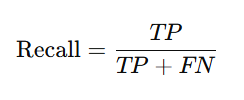

The model is only predicting non-goals so it is going to miss every single goal. The model can't even be right about goals. Therefore, the true positive is going to equal zero. That is why recall is zero.

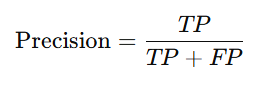

The model is never even trying to predict a goal, so it can't have any correct or false positive predictions. The true positive and false positive both equal zero. Therefore, precision is going to equal zero.

# Logistic Regression


First, let us try to run our logistic regression model without addressing the class imbalance. Make a prediciton: Do you think our model will outperform the baseline model?

In [ ]:
#Make sure I have a binary outcome column (goal) and then also convert assissted column to binary
df["assist_binary"] = (df["Assisted"] == "Assisted").astype(int)
df["assist_binary"].value_counts()

In [ ]:
#Normalize with a pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

In [ ]:
#Coefficient Table
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": pipeline.named_steps["logreg"].coef_[0]
}).sort_values("Coefficient", ascending = False)

coef_table

Logistic Regression coefficient table gives us the log odds not the probabilities. How do we convert the log odds into the actual odds?

What do the coefficients tell us about our features?

In [ ]:
# Performance Metrics
probs_test = pipeline.predict_proba(X_test)[:, 1]
log_test_pred = pipeline.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
log_acc = accuracy_score(y_test, log_test_pred)
log_precision = precision_score(y_test, log_test_pred, average = "weighted")
log_recall = recall_score(y_test, log_test_pred, average = "weighted")
log_f1 = f1_score(y_test, log_test_pred, average = "weighted")
log_auc = roc_auc_score(y_test, probs_test)

#Results
log_results = {
    "Model": ['Logistic Regression'],
    'Accuracy': [log_acc],
    'Precision': [log_precision],
    'Recall': [log_recall],
    'F1-Score': [log_f1],
    'AUC': [log_auc]
}
log_results = pd.DataFrame(log_results)
log_results.head()

In [ ]:
#Plot ROC Curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, probs_test)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {log_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# SVM

First, let us try to run our SVM model without addressing the class imbalance. Make a prediciton: Do you think our model will outperform the baseline model?

In [ ]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel = 'linear', C = 1, probability = True))
])

svm_pipeline.fit(X_train, y_train)

svm_test_pred = svm_pipeline.predict(X_test)
svm_probs = svm_pipeline.predict_proba(X_test)

In [ ]:
svm_acc = accuracy_score(y_test, svm_test_pred)
svm_precision = precision_score(y_test, svm_test_pred, average = "weighted")
svm_recall = recall_score(y_test, svm_test_pred, average = "weighted")
svm_f1 = f1_score(y_test, svm_test_pred, average = "weighted")
svm_auc = roc_auc_score(y_test, svm_probs[:, 1]) #probability for the positive class

In [ ]:
svm_results = {
    "Model": ['SVM'],
    'Accuracy': [svm_acc],
    'Precision': [svm_precision],
    'Recall': [svm_recall],
    'F1-Score': [svm_f1],
    'AUC': [svm_auc]
}
svm_results = pd.DataFrame(svm_results)
svm_results.head()
#CDT Treacy helped with the svm code

In [ ]:
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": svm_pipeline.named_steps["svm"].coef_[0]
}).sort_values("Coefficient", ascending=False)

coef_table

Since this is an SVM, the coefficient table is different from the one we did for our logistic regression model. The SVM coefficients are defining the decision boundary for our classification of Goal or No Goal. The coefficients do not correlate to the odds of a goal increasing or decreasing by x%. A larger coefficient just means that feature has a stronger influence on how the model separates goals from non-goals.  

Lets see how our first three models compare. What sticks out?

In [ ]:
final_results = pd.concat([dum_results, log_results, svm_results], ignore_index=True)
final_results = final_results.round(3)
final_results = final_results.sort_values(by="AUC", ascending=False)
final_results

# Addressing Class Imbalance

To address the class imbalance in my modeling, I included a parameter in my model that told it to pay more attention to the minority class (goals) and less to the majority class (no goals) when learning. This is considered “balancing” the dataset because the model is forced to care about detecting goals instead of cheating by predicting mostly no goals.

In [ ]:
# Balanced Pipeline

pipeline_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000))
])

pipeline_balanced.fit(X_train, y_train)

In [ ]:
#Coefficient Table
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": pipeline_balanced.named_steps["logreg"].coef_[0]
}).sort_values("Coefficient", ascending = False)

coef_table

In [ ]:
# Performance Metrics
probs2_test = pipeline_balanced.predict_proba(X_test)[:, 1]
log2_test_pred = pipeline_balanced.predict(X_test)

log2_acc = accuracy_score(y_test, log2_test_pred)
log2_precision = precision_score(y_test, log2_test_pred)
log2_recall = recall_score(y_test, log2_test_pred)
log2_f1 = f1_score(y_test, log2_test_pred)
log2_auc = roc_auc_score(y_test, probs2_test)

#Results
log2_results = {
    "Model": ['Balanced Logistic Regression'],
    'Accuracy': [log2_acc],
    'Precision': [log2_precision],
    'Recall': [log2_recall],
    'F1-Score': [log2_f1],
    'AUC': [log2_auc]
}
log2_results = pd.DataFrame(log2_results)
log2_results.head()

Now, lets balance our SVM model and see how it performs.

In [ ]:
# Balanced SVM Pipeline

svm_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="linear",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

svm_balanced.fit(X_train, y_train)

svm2_pred = svm_balanced.predict(X_test)
svm2_prob = svm_balanced.predict_proba(X_test)[:, 1]

In [ ]:
# Performance Metrics

svm2_acc = accuracy_score(y_test, svm2_pred)
svm2_precision = precision_score(y_test, svm2_pred)
svm2_recall = recall_score(y_test, svm2_pred)
svm2_f1 = f1_score(y_test, svm2_pred)
svm2_auc = roc_auc_score(y_test, svm2_prob)

svm2_results = {
    "Model": ['Balanced SVM'],
    'Accuracy': [svm2_acc],
    'Precision': [svm2_precision],
    'Recall': [svm2_recall],
    'F1-Score': [svm2_f1],
    'AUC': [svm2_auc]
}
svm2_results = pd.DataFrame(svm2_results)
svm2_results.head()

In [ ]:
final_results = pd.concat([log_results, svm_results, log2_results, svm2_results], ignore_index=True)
final_results = final_results.round(4)
final_results = final_results.sort_values(by="AUC", ascending=False)
final_results

# Multinomial Logistic Regression

I can turn this into a multiclass classification problem. I am going to make my response into 5 categories:


*   OFF = 0
*   GOAL = 1
*   MESSY SAVE = 2
*   CLEAN SAVE = 3
*   PIPE = 4







In [ ]:
df = df.dropna(subset=["Result"])
df["Result"].unique()

#Redefine y for multinomial
X = df[["shot_distance", "true_angle_deg", "assist_binary"]]
y = df["Result"]

# New train/test split for this new target
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
multi_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class = "multinomial",
        solver = "lbfgs",
        max_iter = 1000
    ))
])

multi_pipeline.fit(X_train, y_train)

In [ ]:
# Predictions
multi_test_pred = multi_pipeline.predict(X_test)
multi_probs = multi_pipeline.predict_proba(X_test)

In [ ]:
# Sanity Check
print(multi_pipeline.named_steps["logreg"].classes_)
print(multi_probs.shape)

In [ ]:
# Metrics
multi_acc = accuracy_score(y_test, multi_test_pred)
multi_prec = precision_score(y_test, multi_test_pred, average = "weighted")
multi_recall = recall_score(y_test, multi_test_pred, average = "weighted")
multi_f1 = f1_score(y_test, multi_test_pred, average = "weighted")
multi_auc = roc_auc_score(y_test, multi_probs, multi_class = "ovr")

multi_results = {
    "Model": ['Multinomial Logistic'],
    'Accuracy': [multi_acc],
    'Precision': [multi_prec],
    'Recall': [multi_recall],
    'F1-Score': [multi_f1],
    'AUC': [multi_auc]
}
multi_results = pd.DataFrame(multi_results)
multi_results.head()

In [ ]:
coef_table = pd.DataFrame(
    multi_pipeline.named_steps["logreg"].coef_,
    columns=X_train.columns
)

coef_table

In [ ]:
final_results = pd.concat([log_results, svm_results, log2_results, svm2_results, multi_results], ignore_index=True)
final_results = final_results.round(4)
final_results = final_results.sort_values(by="AUC", ascending=False)
final_results

# Interactive Plots

In [ ]:
plt.figure(figsize=(6,8))

# Plot non-goals first (background)
plt.scatter(non_goals["X"], non_goals["Y"],
            alpha=0.05, color="gray", label="Non Goals")

# Plot goals second (on top)
plt.scatter(goals["X"], goals["Y"],
            alpha=0.9, color="red", s=30, label="Goals")

# Goal reference points
plt.scatter(goal_center[0], goal_center[1], color="green", s=20, label="Center of Goal")
plt.scatter(left_post[0], left_post[1], color="orange", s=10, label="Left Post")
plt.scatter(right_post[0], right_post[1], color="orange", s=10, label="Right Post")

plt.legend()
plt.title("PLL Shot Chart: Goals vs Non-Goals")

plt.axis("equal")
plt.show()

In [ ]:
pip install plotly

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="X",
    y="Y",
    color="goal",
    color_discrete_map={
        "Goal": "red",
        "Non Goal": "gray"
    },
    hover_data=["Result", "shot_distance", "true_angle_deg"],
    opacity=0.6,
    title="PLL Shot Chart: Goals vs Non Goals"
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_traces(marker=dict(size=6))

fig.show()